In [492]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Load data

In [493]:
save_name_modifier = "_final" # "", "_ablation", "_ablation_small"

In [494]:
# dataset_name = 'GB1'
# MAX_FITNESS = 8.76196565571

# y_limits = [0., 8.8]
# y_limits_std = [0., 1.8]
# y_limits_wt = [1., 8.85]
# CLADE = True

In [495]:
# dataset_name = 'PhoQ'
# MAX_FITNESS = 133.59427

# y_limits = [0., 60.]
# y_limits_std = [0., 35.]
# y_limits_wt = [0., 70.]
# CLADE = True

In [496]:
dataset_name = 'TrpB'
MAX_FITNESS = 1.0 # Dataset is already normalized.

y_limits = [0., 1.01]
y_limits_std = [0., 0.4]
y_limits_wt = [0., 1.01]
CLADE = False

In [497]:
labels = []

# DE benchmarks
smw_file_name = 'de/smw_'+dataset_name+'_all.pkl'
labels.append('SMW')
recombine_file_name = 'de/recombination_'+dataset_name+'.pkl'
labels.append('Recombination')

# BOES
DIM1 = 1280
DIM2 = 50
boes_file_names = []
boes_file_names.append('boes/'+dataset_name+'/original_1280.pkl')
labels.append('BOES matérn32')
boes_file_names.append('boes/'+dataset_name+'/matern_'+str(DIM1)+'.pkl')
labels.append('BOES')
boes_file_names.append('boes/'+dataset_name+'/conic_'+str(DIM1)+'.pkl')
labels.append('BOES cylindrical')
boes_file_names.append('boes/'+dataset_name+'/additive_'+str(DIM1)+'.pkl')
labels.append('BOES additive')
boes_file_names.append('boes_bug_fixed/'+dataset_name+'/matern_'+str(DIM2)+'.pkl')
labels.append('BOES 50')
boes_file_names.append('boes_bug_fixed/'+dataset_name+'/conic_'+str(DIM2)+'.pkl')
labels.append('BOES cylindrical 50')
boes_file_names.append('boes_bug_fixed/'+dataset_name+'/additive_'+str(DIM2)+'.pkl')
labels.append('BOES additive 50')

# BOES ablation study
boes_file_names.append('boes/'+dataset_name+'/onehot.pkl')
labels.append('BOES onehot')
boes_file_names.append('boes/'+dataset_name+'/ucb.pkl')
labels.append('BOES UCB')
boes_file_names.append('boes/'+dataset_name+'/ucb_onehot.pkl')
labels.append('BOES UCB onehot')
boes_file_names.append('boes/'+dataset_name+'/ucb_onehot_hyper.pkl')
labels.append('BO trivial')

# ODBO
odbo_file_names = []
odbo_file_names.append('odbo/results/'+dataset_name+'_BO_GP_all.pkl')
labels.append('ODBO BO GP')
odbo_file_names.append('odbo/results/'+dataset_name+'_ODBO_TuRBO_RobustGP_all.pkl')
labels.append('ODBO full')

# CLADE
if CLADE:
    clade_file_name = 'clade/' + dataset_name + '/budget_190/fitness_progressions.npy'
    labels.append('CLADE 2.0')

In [498]:
all_fitness_progressions = []

with open("../PELLM/data/"+dataset_name+"/sampled_starting_variants_1000.pkl", 'rb') as f:
    sampled_starting_variants = pickle.load(f)[0]

# DE benchmarks
with open(smw_file_name, 'rb') as f:
    smw_start_variants, smw_final_variants, smw_fitness_progressions = pickle.load(f)
#all_fitness_progressions.append(np.array(smw_fitness_progressions))
filtered_smw_fitness_progressions = []
for variant in sampled_starting_variants[0:100]:
    if variant in smw_start_variants:
        index = smw_start_variants.index(variant)
        filtered_smw_fitness_progressions.append(smw_fitness_progressions[index])
all_fitness_progressions.append(np.array(filtered_smw_fitness_progressions))

with open(recombine_file_name, 'rb') as f:
    recombine_best_variants, recombine_fitness_progressions = pickle.load(f)
def unify_fitness_progressions(fitness_progressions):
    """ rfpl = []
    for i in range(len(fitness_progressions)):
        rfpl.append(len(fitness_progressions[i]))
    max_rfpl = max(rfpl) """
    max_rfpl = 191
    for i in range(len(fitness_progressions)):
        fitness_progressions[i] = fitness_progressions[i] + (max_rfpl - len(fitness_progressions[i]))*[fitness_progressions[i][-1]]
        fitness_progressions[i] = fitness_progressions[i][0:max_rfpl]
    return fitness_progressions
recombine_fitness_progressions = unify_fitness_progressions(recombine_fitness_progressions)
all_fitness_progressions.append(np.array(recombine_fitness_progressions[0:100]))

# BOES
for file_name in boes_file_names:
    with open(file_name, 'rb') as f:
        boes_fitness_progressions = np.array(pickle.load(f)[0]) * MAX_FITNESS
    all_fitness_progressions.append(boes_fitness_progressions)

# ODBO
for file_name in odbo_file_names:
    with open(file_name, 'rb') as f:
        odbo_fitness_progressions = np.array(pickle.load(f)) * MAX_FITNESS
    all_fitness_progressions.append(odbo_fitness_progressions)

# CLADE
if CLADE:
    with open(clade_file_name, 'rb') as f:
        clade_fitness_progressions = np.load(f) * MAX_FITNESS
    all_fitness_progressions.append(clade_fitness_progressions)

In [499]:
print(len(all_fitness_progressions))

15


In [500]:
# CLADE
if CLADE:
    clade_data_dists = {}
    for budget in [50, 100, 150, 190]:
        clade_file_name = 'clade/'+dataset_name+'/budget_'+str(budget)+'/max_fitnesses.npy'
        with open(clade_file_name, 'rb') as f:
            _dist = np.load(f) * MAX_FITNESS
        clade_data_dists[budget] = _dist

# Plot CDF and final fitnesses

In [501]:
all_counts = []
all_bins = []
all_bin_centers = []

all_sorted_fitnesses = []
all_cdf_values = []

def prepare_final_fitnesses(fitness_progressions):
    final_fitnesses = []
    for progression in fitness_progressions:
        final_fitnesses.append(progression[-1])

    return final_fitnesses

def prepare_cdf_data(final_fitnesses):
    final_fitnesses_sorted = np.sort(final_fitnesses)
    n = len(final_fitnesses_sorted)
    cdf_values = 1. * np.arange(n) / (n - 1)

    all_sorted_fitnesses.append(final_fitnesses_sorted)
    all_cdf_values.append(cdf_values)

for fp in all_fitness_progressions:
    prepare_cdf_data(prepare_final_fitnesses(fp))


In [502]:
all_means = []
all_medians = []
all_first_q = []
all_third_q = []
for fitness in all_sorted_fitnesses:
    all_means.append(np.mean(fitness))
    all_medians.append(np.median(fitness))
    all_first_q.append(np.quantile(fitness, 0.25))
    all_third_q.append(np.quantile(fitness, 0.75))

print(labels)
print(all_means)
print(all_first_q)
print(all_medians)
print(all_third_q)

['SMW', 'Recombination', 'BOES matérn32', 'BOES', 'BOES cylindrical', 'BOES additive', 'BOES 50', 'BOES cylindrical 50', 'BOES additive 50', 'BOES onehot', 'BOES UCB', 'BOES UCB onehot', 'BO trivial', 'ODBO BO GP', 'ODBO full']
[np.float64(0.41583994435), np.float64(0.6170944637400001), np.float64(0.9552219986), np.float64(0.9232490715), np.float64(0.9358630465000001), np.float64(0.4535033091), np.float64(0.9596219264), np.float64(0.9157447399), np.float64(0.4490915845), np.float64(0.9134686956), np.float64(0.9639651543), np.float64(0.8914381881), np.float64(0.7667993260000001), np.float64(0.6826331251000001), np.float64(0.7236088554)]
[np.float64(0.0788722425), np.float64(0.5082820125), np.float64(0.9071677175), np.float64(0.7528948), np.float64(0.903386675), np.float64(0.3486983925), np.float64(1.0), np.float64(0.7528948), np.float64(0.3282572925), np.float64(0.83257025), np.float64(1.0), np.float64(0.7528948), np.float64(0.72526836), np.float64(0.5858075975), np.float64(0.64414717)]

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_67023/1245041734.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axs[0].boxplot(


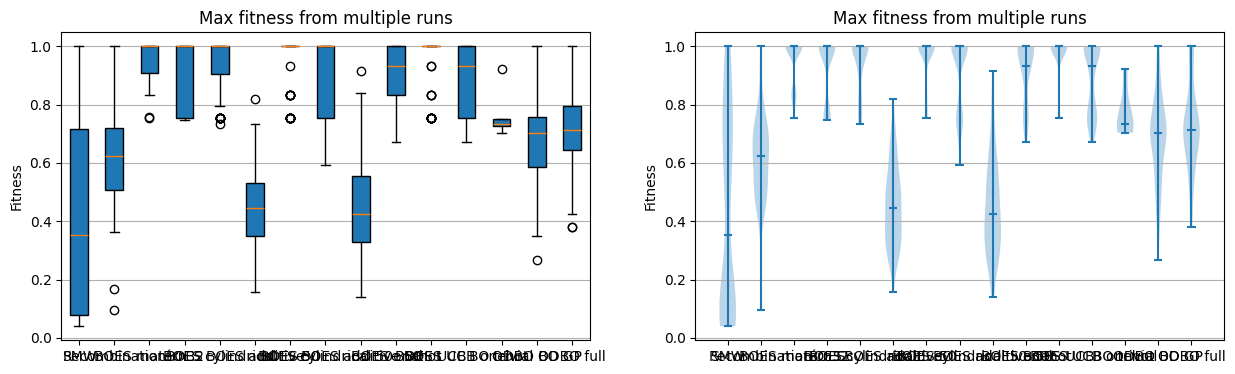

In [503]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
bplot = axs[0].boxplot(
    all_sorted_fitnesses,
    vert=True,  # vertical box alignment
    patch_artist=True,  # fill with color
    labels=labels,
)

axs[1].violinplot(all_sorted_fitnesses,
                  showmeans=False,
                  showmedians=True)
axs[1].set_title('Violin plot')

for ax in axs:
    ax.set_title("Max fitness from multiple runs")
    ax.yaxis.grid(True)
    ax.set_xticks([y + 1 for y in range(len(all_sorted_fitnesses))],
                  labels=labels)
    #ax.set_xlabel('')
    ax.set_ylabel('Fitness')

# Plot fitness progressions

Plot all runs

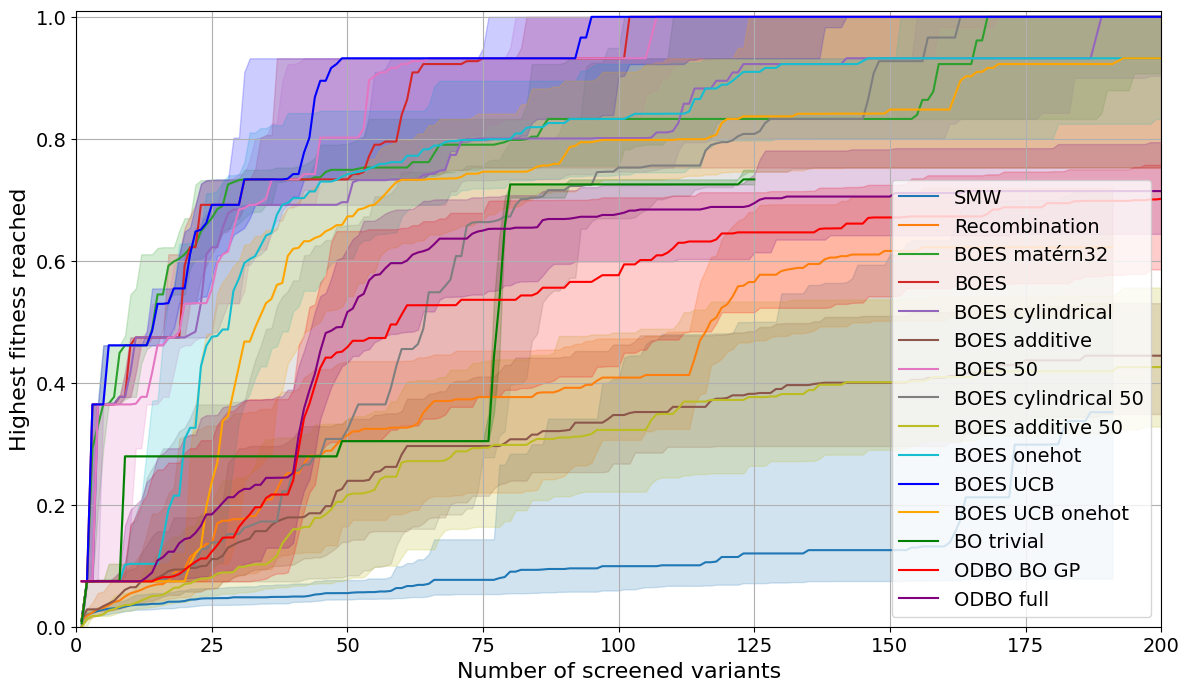

In [504]:

def tsplot(ax, data, label, **kw):
    x = np.arange(data.shape[1]) + 1
    
    #est = np.mean(data, axis=0)
    est = np.median(data, axis=0)
    
    #sd = np.std(data, axis=0)
    #cis = (est - sd, est + sd)
    cis = (np.quantile(data, 0.25, axis=0), np.quantile(data, 0.75, axis=0))

    ax.plot(x,est,**kw,label=label)
    ax.fill_between(x,cis[0],cis[1],alpha=0.2, **kw)
    ax.margins(x=0)

fig, (ax) = plt.subplots(ncols=1, figsize=(14,8), sharey=True)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
i = 0
for fp in all_fitness_progressions:
    tsplot(ax, fp, color=colors[i], label=labels[i])
    i += 1

default_fontsize = 14
label_fontsize = 16
plt.legend(loc=4, fontsize=default_fontsize)
plt.xlabel("Number of screened variants", fontsize=label_fontsize)
plt.ylabel("Highest fitness reached", fontsize=label_fontsize)
plt.xticks(fontsize=default_fontsize)
plt.yticks(fontsize=default_fontsize)
ax.set_ylim(y_limits)
ax.set_xlim([0, 200])
#fig.axes[0].set_aspect(25) # GB1
#fig.axes[0].set_aspect(4) # PhoQ
plt.grid()
plt.show()

# fig.savefig('results/' + dataset_name + save_name_modifier + '_fitness_progression.png', bbox_inches='tight') # dpi=300

SOTA comparison

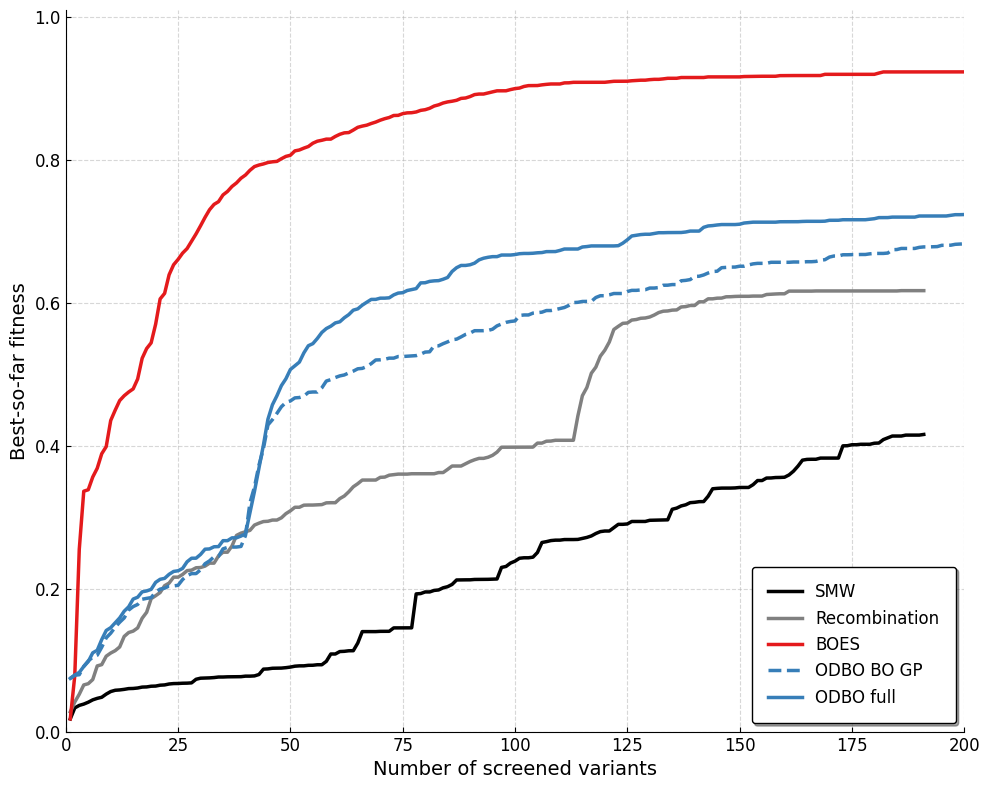

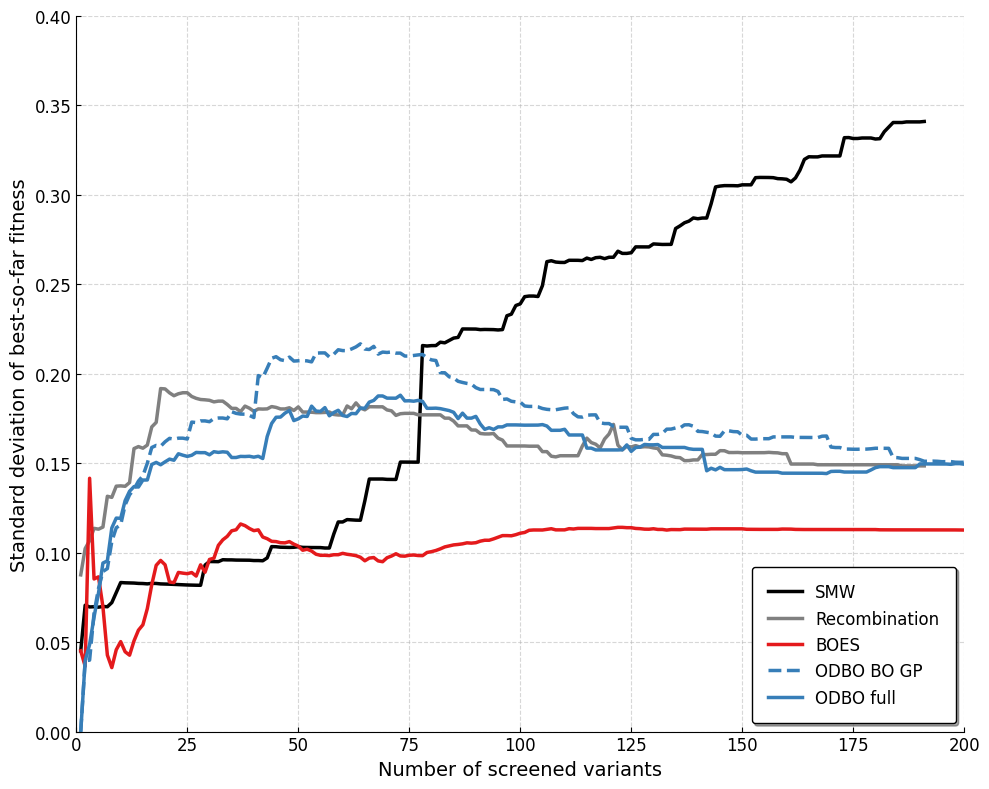

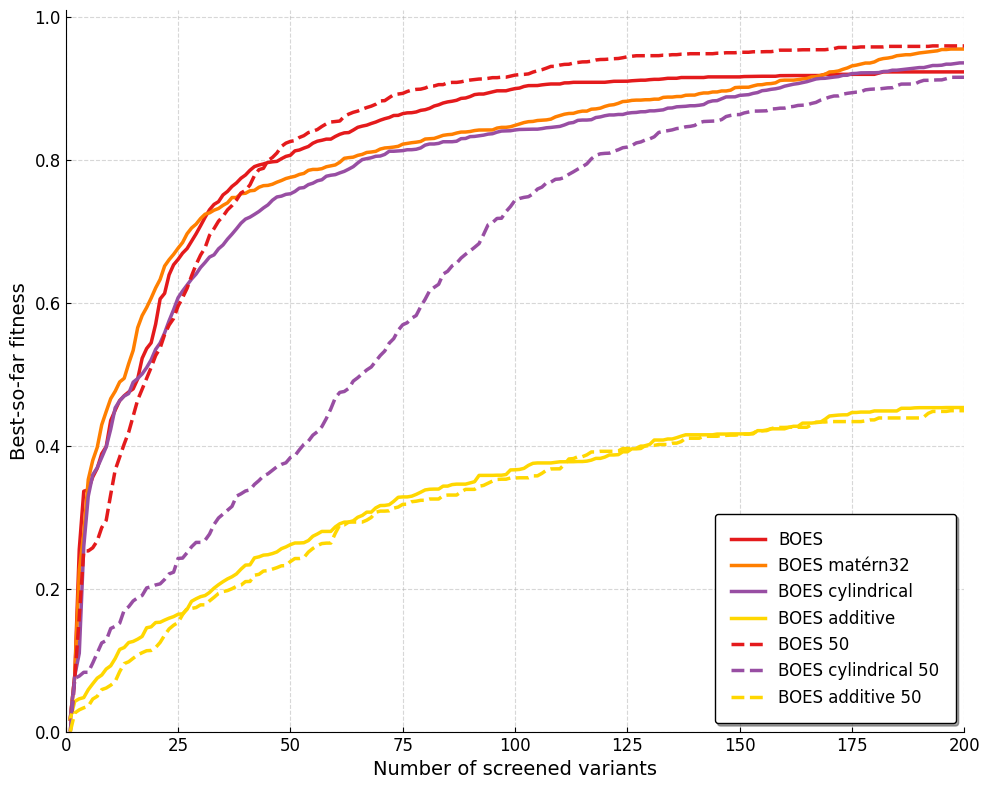

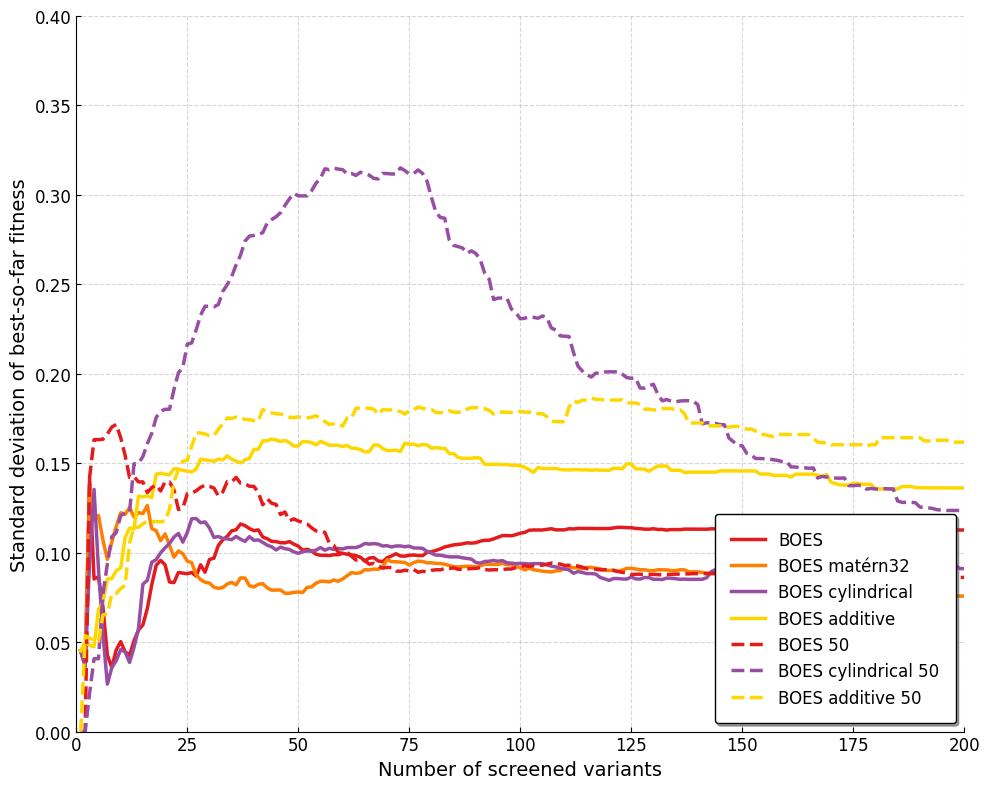

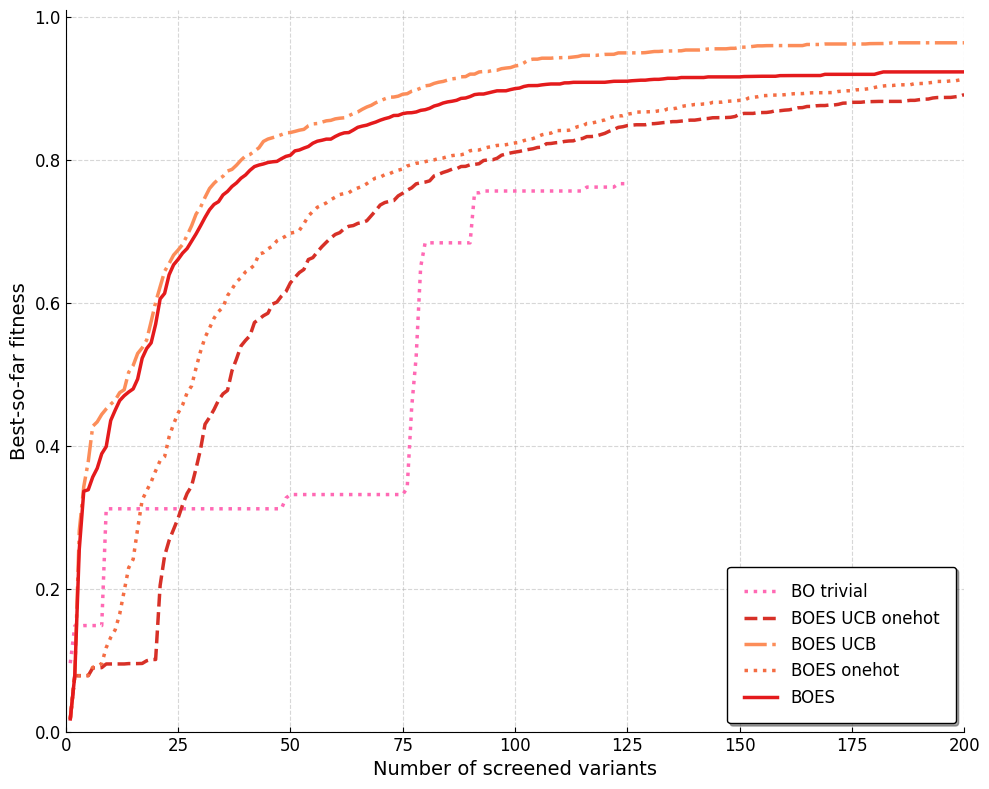

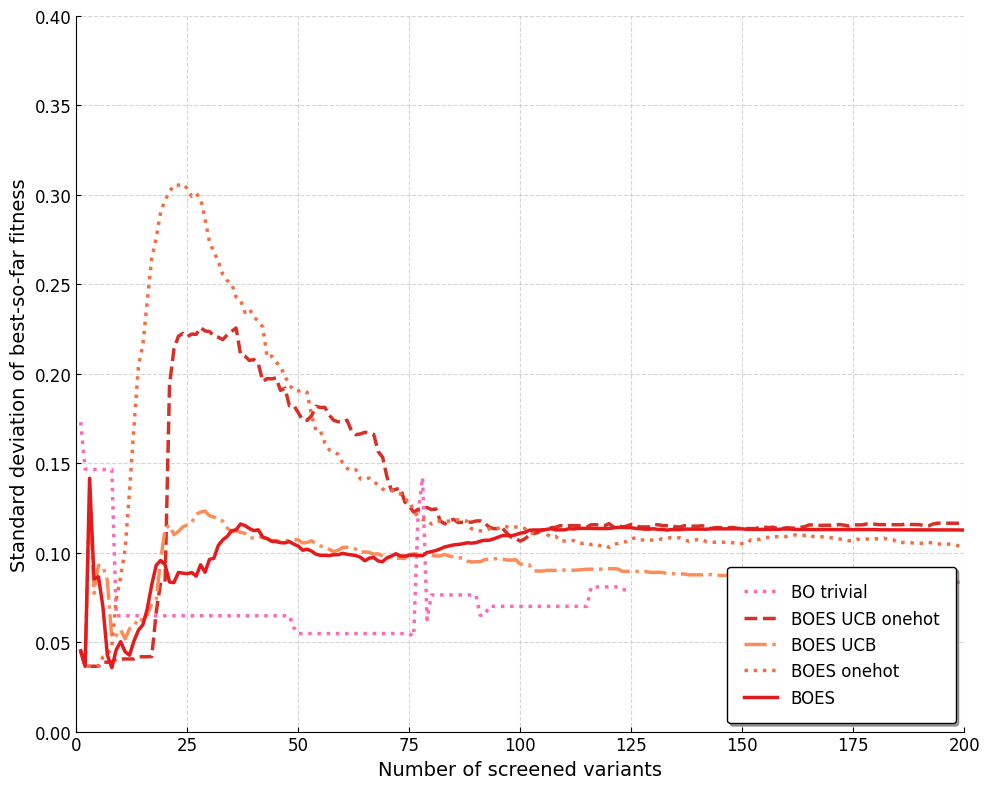

In [505]:
# SOTA labels and fitness progressions
selected_labels = ["SMW", "Recombination", "BOES", "ODBO BO GP", "ODBO full", "CLADE 2.0"]
selected_indices = [labels.index(label) for label in selected_labels if label in labels]
filtered_labels = [labels[i] for i in selected_indices]
filtered_fitness_progressions = [all_fitness_progressions[i] for i in selected_indices]

# Kernel labels and fitness progressions
new_labels = ["BOES", "BOES matérn32", "BOES cylindrical", "BOES additive", "BOES 50", "BOES matérn32 50", "BOES cylindrical 50", "BOES additive 50"]
new_indices = [labels.index(label) for label in new_labels if label in labels]
new_filtered_labels = [labels[i] for i in new_indices]
new_filtered_fitness_progressions = [all_fitness_progressions[i] for i in new_indices]

# Ablation study labels and fitness progressions
ablation_labels = ["BO trivial", "BOES UCB onehot", "BOES UCB", "BOES onehot", "BOES"]
ablation_indices = [labels.index(label) for label in ablation_labels if label in labels]
ablation_filtered_labels = [labels[i] for i in ablation_indices]
ablation_filtered_fitness_progressions = [all_fitness_progressions[i] for i in ablation_indices]

# Use Set1 color palette and customize for all methods
colors = []
linestyles = []

# Customize colors and linestyles for specific methods
method_color_map = {
    "SMW": '#000000',  # Black
    "Recombination": '#808080',  # Grey
    "BOES": '#e41a1c',  # Red
    "BOES 50": '#e41a1c',  # Red
    "ODBO BO GP": '#377eb8',  # Blue
    "ODBO full": '#377eb8',  # Blue
    "CLADE 2.0": '#4daf4a',  # Green,
    "BOES matérn32": '#ff7f00',  # Orange
    "BOES cylindrical": '#984ea3',  # Purple
    "BOES additive": '#ffd700',  # Darker Yellow,
    "BOES matérn32 50": '#ff7f00',  # Orange
    "BOES cylindrical 50": '#984ea3',  # Purple
    "BOES additive 50": '#ffd700',  # Darker Yellow,
    "BO trivial": '#ff69b4',  # Non-aggressive pink
    "BOES UCB onehot": '#d73027',  # Slightly darker red
    "BOES UCB": '#fc8d59',  # Lighter red-orange
    "BOES onehot": '#f46d43'  # Medium red-orange
}

method_linestyle_map = {
    "SMW": '-',
    "Recombination": '-',
    "BOES": '-',
    "BOES 50": '--',
    "ODBO BO GP": '--',
    "ODBO full": '-',
    "CLADE 2.0": '-',
    "BOES matérn32": '-',
    "BOES cylindrical": '-',
    "BOES additive": '-',
    "BOES matérn32 50": '--',
    "BOES cylindrical 50": '--',
    "BOES additive 50": '--',
    "BO trivial": ':',
    "BOES UCB onehot": '--',
    "BOES UCB": '-.',
    "BOES onehot": ':'
}

for i, label in enumerate(selected_labels + new_labels + ablation_labels):
    if label in method_color_map:
        colors.append(method_color_map[label])
    if label in method_linestyle_map:
        linestyles.append(method_linestyle_map[label])

# Iterate over the four cases: mean and standard deviation for both sets of data
for metric, title, ylabel, filename_suffix, data_labels, data_progressions in zip(
    ["mean", "std", "mean", "std", "mean", "std"],
    [
        "Mean fitness progressions for SOTA methods",
        "Standard deviation of fitness progressions for SOTA methods",
        "Mean fitness progressions for different kernels and dimensions",
        "Standard deviation of fitness progressions for different kernels and dimensions",
        "Mean fitness progressions for ablation methods",
        "Standard deviation of fitness progressions for ablation methods"
    ],
    [
        "Best-so-far fitness",
        "Standard deviation of best-so-far fitness",
        "Best-so-far fitness",
        "Standard deviation of best-so-far fitness",
        "Best-so-far fitness",
        "Standard deviation of best-so-far fitness"
    ],
    ["_SOTA_mean", "_SOTA_std", "_kernels_mean", "_kernels_std", "_ablation_mean", "_ablation_std"],
    [filtered_labels, filtered_labels, new_filtered_labels, new_filtered_labels, ablation_filtered_labels, ablation_filtered_labels],
    [filtered_fitness_progressions, filtered_fitness_progressions, new_filtered_fitness_progressions, new_filtered_fitness_progressions, ablation_filtered_fitness_progressions, ablation_filtered_fitness_progressions]
):
    fig, ax = plt.subplots(figsize=(10, 8))  # Create a separate figure for each case
    for i, (label, fp) in enumerate(zip(data_labels, data_progressions)):
        if metric == "mean":
            progression = np.mean(fp, axis=0)
        elif metric == "std":
            progression = np.std(fp, axis=0)
        
        ax.plot(
            np.arange(1, len(progression) + 1),
            progression,
            label=label,
            color=method_color_map.get(label, '#000000'),
            linestyle=method_linestyle_map.get(label, '-'),
            linewidth=2.5  # Increased line width
        )

    # Customize the plot
    # ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel("Number of screened variants", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_ylim(y_limits if metric == "mean" else y_limits_std)  # Adjust y-limits
    ax.set_xlim([0, 200])
    ax.legend(fontsize=12, loc='lower right' if metric == "mean" else 'lower right', frameon=True, fancybox=True, shadow=True, borderpad=1, edgecolor='black')
    ax.grid(alpha=0.5, linestyle='--')  # Make grid lines lighter and dashed

    # Make tick numbers bigger and point ticks inwards
    ax.tick_params(axis='both', which='major', labelsize=12, direction='in')

    # Remove the right and top borders
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Save the figure
    fig.savefig('results/' + dataset_name + save_name_modifier + filename_suffix + '.png', bbox_inches='tight')  # Save each plot separately


Plot WT (single) runs

In [506]:
# fig, (ax) = plt.subplots(ncols=1, figsize=(14,7), sharey=True)
# colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple', 'tab:gray']
# i = 0
# for fitness_progression in single_fitness_progressions:
#     ax.plot(np.arange(len(fitness_progression)), fitness_progression, color=colors[i])
#     i += 1
# 
# ax.plot(mlde_od_budgets, mlde_od_best_so_far, 'o ', color=colors[3])
# ax.plot(finetune_budgets, finetune_best_so_far, 'o ', color=colors[4])
# 
# default_fontsize = 14
# label_fontsize = 16
# plt.legend(single_labels, loc=4, fontsize=default_fontsize)
# plt.xlabel("Number of screened variants", fontsize=label_fontsize)
# plt.ylabel("Highest fitness reached", fontsize=label_fontsize)
# plt.xticks(fontsize=default_fontsize)
# plt.yticks(fontsize=default_fontsize)
# ax.set_ylim(y_limits_wt)
# ax.set_xlim([0, 384])
# #fig.axes[0].set_aspect(25) # GB1
# #fig.axes[0].set_aspect(4) # PhoQ
# plt.grid()
# plt.show()

15
15
['SMW', 'Recomb.', 'BOES matérn32', 'BOES', 'BOES cylindrical', 'BOES additive', 'BOES 50', 'BOES cylindrical 50', 'BOES additive 50', 'BOES onehot', 'BOES UCB', 'BOES UCB onehot', 'BO trivial', 'ODBO BO GP', 'ODBO full']


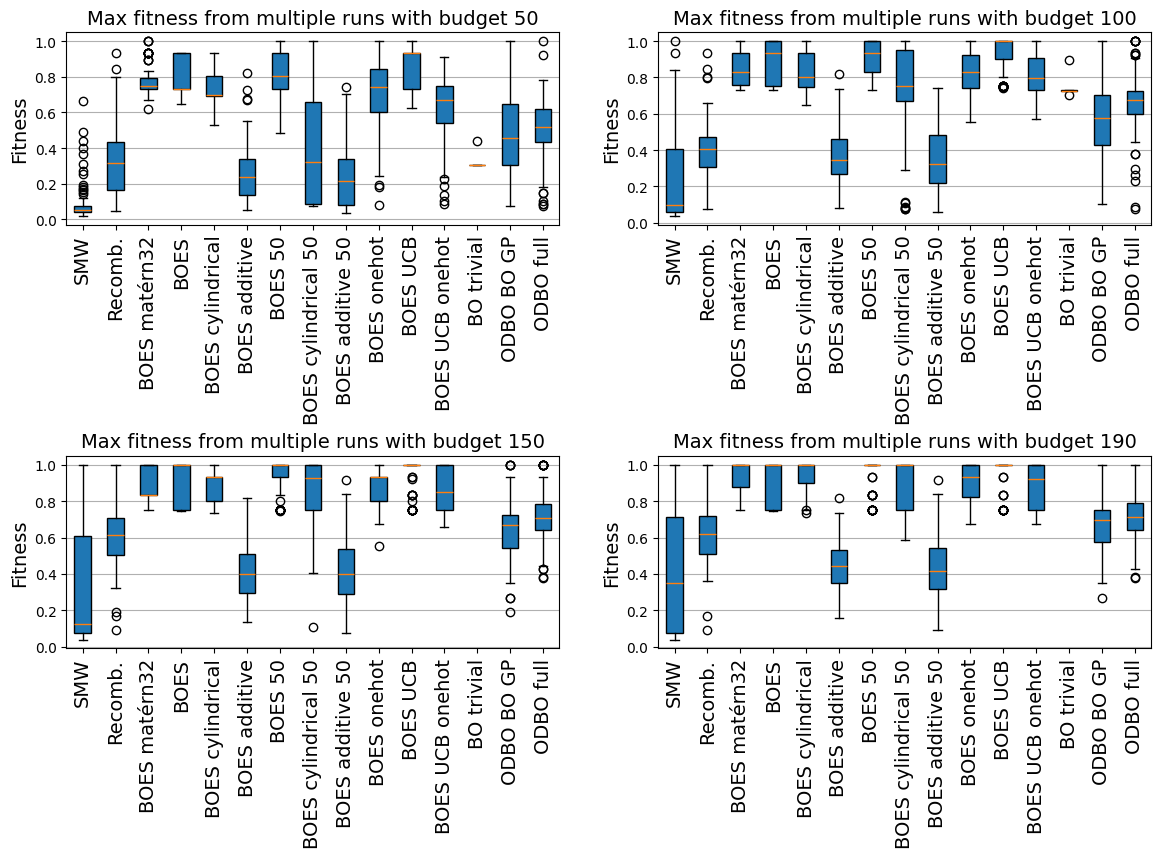

In [507]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), gridspec_kw={'hspace': 1.2})
default_fontsize = 14
budgets = [50, 100, 150, 190]
violin_labels = [l for l in labels]
violin_labels[1] = "Recomb."

def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

data_dists = []
if CLADE:
    assert labels[-1] == "CLADE 2.0"
    fitprogs = all_fitness_progressions[:-1]
else:
    fitprogs = all_fitness_progressions
for budget in budgets:
    data_dists.append([])
    for fp, label in zip(fitprogs, labels):
        if label == "BO trivial":
            data_dists[-1].append(fp[:, budget-1] if budget not in [150, 190] else [])
        else:
            data_dists[-1].append(fp[:, budget-1])

if CLADE:
   #violin_labels.append("CLADE 2.0")
   for b in range(len(budgets)):
       data_dists[b].append(clade_data_dists[budgets[b]])

print(len(data_dists[0]))
print(len(violin_labels))
print(violin_labels)

a = 0
for ax_row in axs:
    for ax in ax_row:
        bplot = ax.boxplot(
            data_dists[a],
            vert=True,  # vertical box alignment
            patch_artist=True,  # fill with color
        )

        # ax.set_title('Violin plot')
        ax.set_title(
            f"Max fitness from multiple runs with budget {budgets[a]}",
            fontsize=default_fontsize,
        )
        ax.yaxis.grid(True)
        ax.set_xticks(
            [y + 1 for y in range(len(data_dists[a]))],
            labels=violin_labels,
            fontsize=default_fontsize,
            rotation='vertical'
        )
        # ax.set_xlabel('')
        ax.set_ylabel("Fitness", fontsize=default_fontsize)

        a += 1

# plt.savefig('results/' + dataset_name + save_name_modifier + '_box.png', bbox_inches='tight') # dpi=300

5
5
['SMW', 'Recombination', 'BOES', 'ODBO BO GP', 'ODBO full']
(5, 4)
7
7
['BOES', 'BOES matérn32', 'BOES cylindrical', 'BOES additive', 'BOES 50', 'BOES cylindrical 50', 'BOES additive 50']
(7, 4)
5
5
['BO trivial', 'BOES UCB onehot', 'BOES UCB', 'BOES onehot', 'BOES']
(5, 4)


/opt/miniconda3/envs/pellm/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/pellm/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/pellm/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/pellm/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/miniconda3/envs/pellm/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


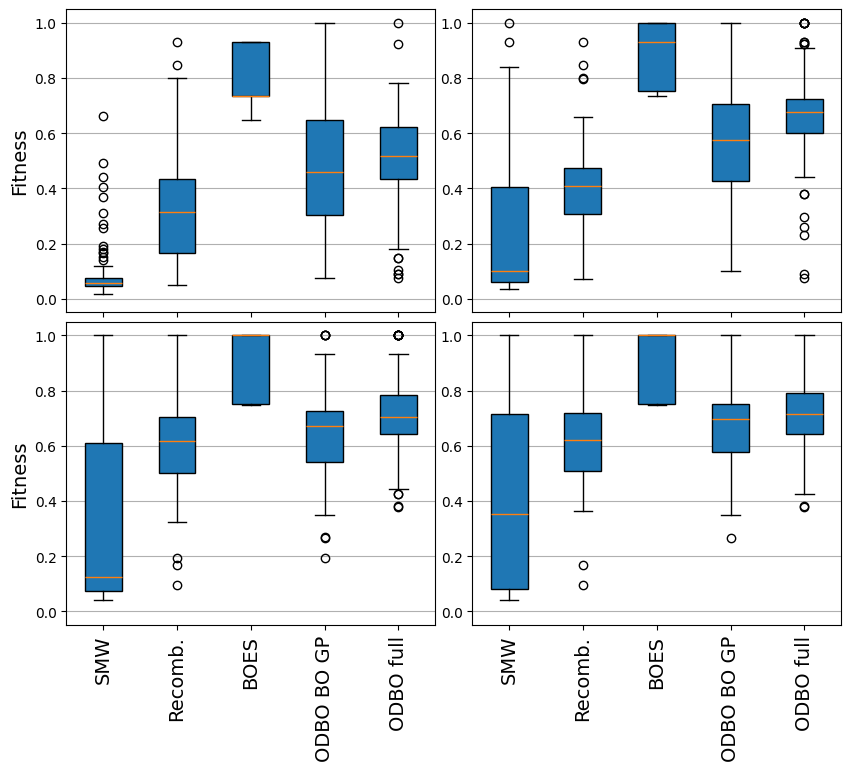

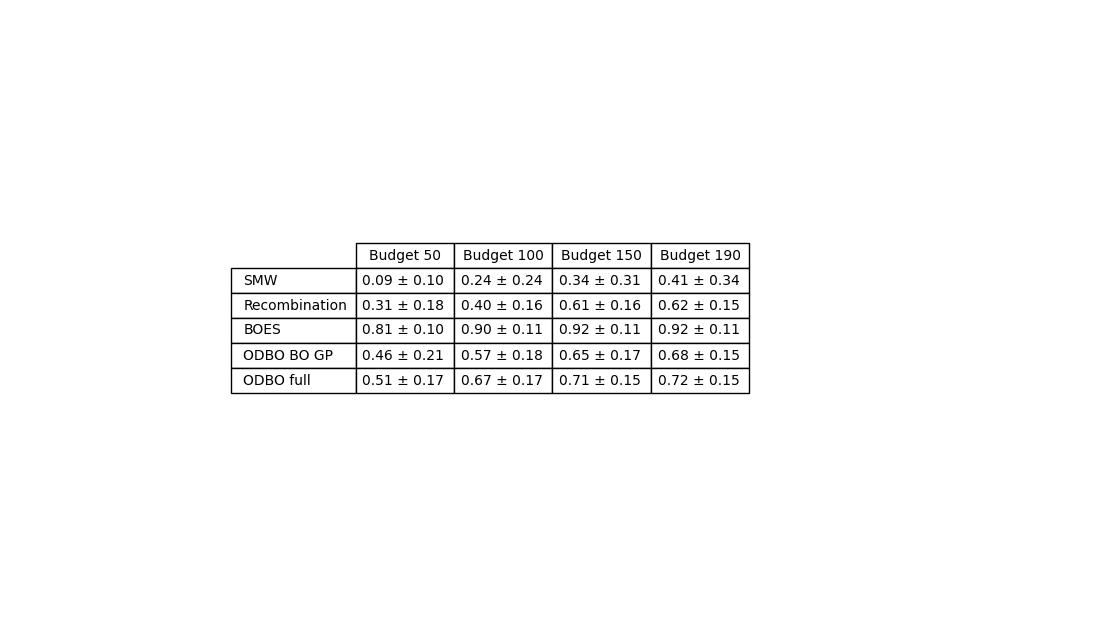

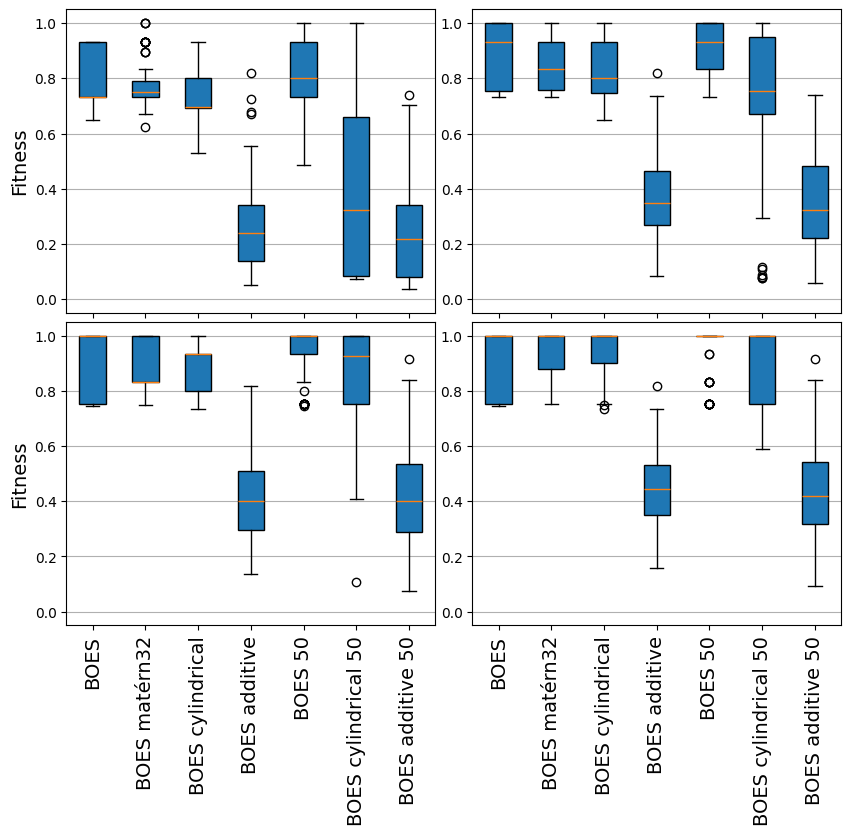

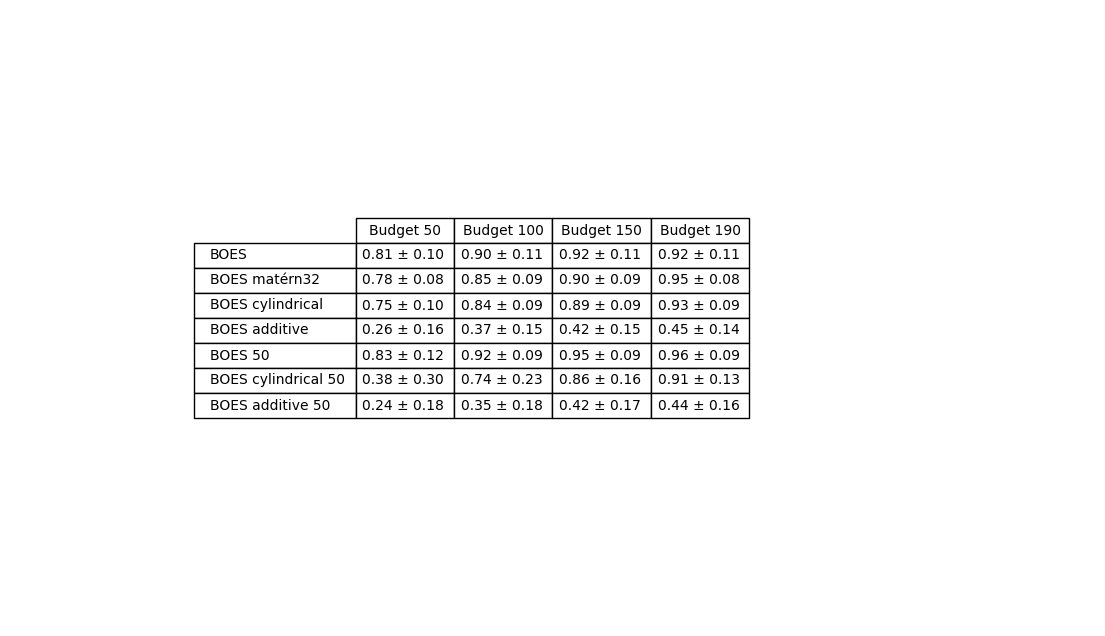

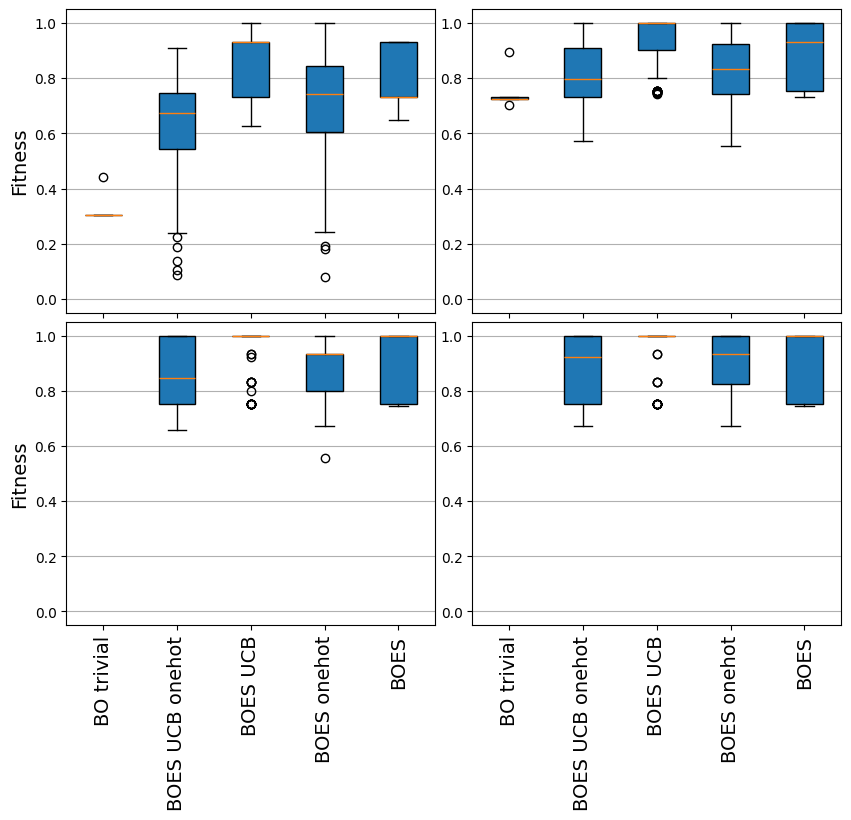

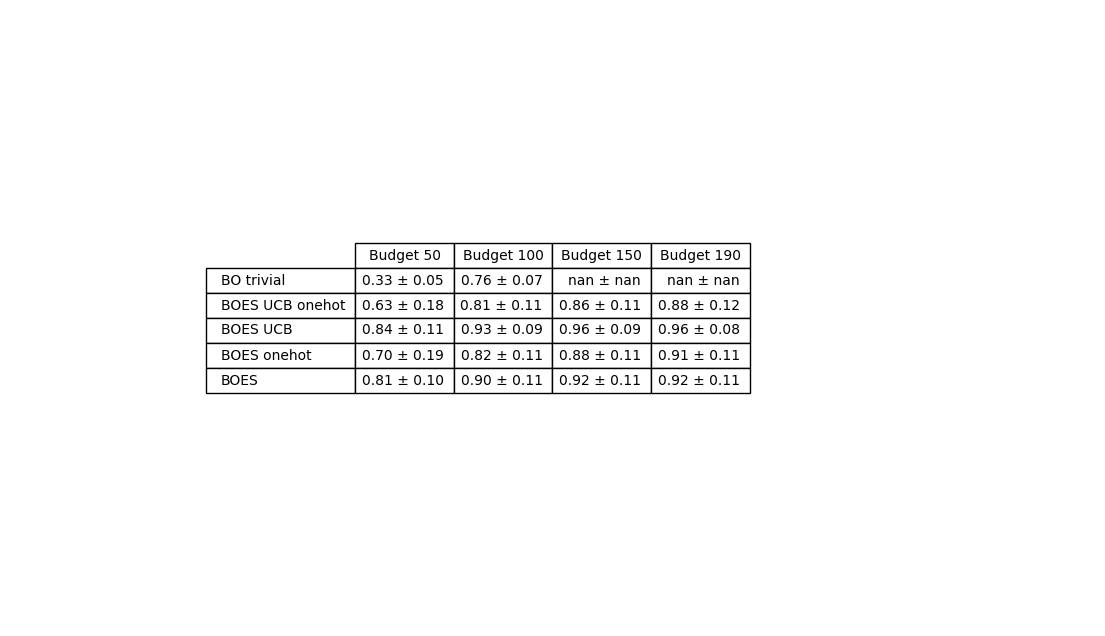

In [508]:
default_fontsize = 14
budgets = [50, 100, 150, 190]
#violin_labels = [l for l in labels]
#violin_labels[1] = "Recomb."

def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

for fitprogs, violin_labels, save_name in zip(
    [filtered_fitness_progressions, new_filtered_fitness_progressions, ablation_filtered_fitness_progressions],
    [filtered_labels, new_filtered_labels, ablation_filtered_labels],
    ["_SOTA", "_kernels", "_ablation"]
):
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), gridspec_kw={'hspace': 0.03, 'wspace': (0.1 if dataset_name == 'TrpB' else 0.075)})
    data_dists = []

    if "CLADE 2.0" in violin_labels:
        assert violin_labels[-1] == "CLADE 2.0"
        fitprogs = fitprogs[:-1]
    
    for budget in budgets:
        data_dists.append([])
        for fp, label in zip(fitprogs, violin_labels):
            if label == "BO trivial":
                data_dists[-1].append(fp[:, budget-1] if budget not in [150, 190] else [])
            else:
                data_dists[-1].append(fp[:, budget-1])

    if "CLADE 2.0" in violin_labels:
       for b in range(len(budgets)):
           data_dists[b].append(clade_data_dists[budgets[b]])

    print(len(data_dists[0]))
    print(len(violin_labels))
    print(violin_labels)

    a = 0
    for ax_row in axs:
        for ax in ax_row:
            bplot = ax.boxplot(
                data_dists[a],
                vert=True,  # vertical box alignment
                patch_artist=True,  # fill with color
            )

            if a < 2:  # For the first two boxplots, keep the x-axis ticks alone with no text
                ax.set_xticks([y + 1 for y in range(len(data_dists[a]))])
                ax.set_xticklabels([])  # Remove text labels
            else:
                ax.set_xticks(
                    [y + 1 for y in range(len(data_dists[a]))],
                    labels=["Recomb." if label == "Recombination" else label for label in violin_labels],
                    fontsize=default_fontsize,
                    rotation=90,  # Rotate the labels to go straight down
                    ha='center'  # Align labels to the center
                )
            
            if a not in [1, 3]:  # Remove y-axis label for the second and fourth boxplot
                ax.set_ylabel("Fitness", fontsize=default_fontsize)
            
            ax.yaxis.grid(True)
            ax.set_ylim([0 - 0.05 * MAX_FITNESS, MAX_FITNESS + 0.05 * MAX_FITNESS])  # Set y-limits with a small margin
            a += 1

    plt.savefig('results/' + dataset_name + save_name_modifier + save_name + '_box.png', bbox_inches='tight') # dpi=300

    # Table results
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 8))
    table_means = [[np.mean(_dist) for _dist in _dists] for _dists in data_dists]
    table_stds = [[np.std(_dist) for _dist in _dists] for _dists in data_dists]
    table_data_formatted = [[f"{table_means[b][m]:.2f} ± {table_stds[b][m]:.2f}" for m in range(len(table_means[b]))] for b in range(len(table_means))]
    table_data_formatted = np.array(table_data_formatted).T
    print(table_data_formatted.shape)
    table = ax.table(cellText=table_data_formatted,
                     rowLabels=violin_labels,
                     colLabels=[f"Budget {b}" for b in budgets],
                     loc='center')
    table.auto_set_column_width(col=list(range(len(budgets))))
    table.scale(1, 1.5)  # Adjust the scale to make the table less wide
    ax.axis('off')
    plt.savefig('results/' + dataset_name + save_name_modifier + save_name + '_table.png', bbox_inches='tight') # dpi=300

Plot time data

In [509]:
import pandas as pd

result = pd.read_csv("time_data.csv")

In [510]:
print(len(result))
result = result.dropna(subset=['kernel', 'dataset', 'dimension', 'times'])
print(len(result))

6375
6375


In [511]:
from copy import deepcopy

additive_times_mean = {}
additive_times_std = {}

kernels = ["Additive", "Matern", "Conic"]
dimensions = [50, 1028]

for kernel in kernels:
    for dimension in dimensions:
        key = f"{kernel}_{dimension}"
        filtered_times = deepcopy(result)
        filtered_times = filtered_times[(filtered_times.kernel == kernel) & (filtered_times.dimension == dimension)]
        filtered_times = filtered_times[filtered_times.dataset == dataset_name].times

        filtered_times = filtered_times.to_numpy()
        filtered_times = [list(map(float, time.strip('[]').split(','))) for time in filtered_times]

        print(len(filtered_times))

        len_pre = len(filtered_times)
        filtered_times = [time for time in filtered_times if len(time) == 200] # TODO change to >= 1280
        print("lost ", len_pre - len(filtered_times), "runs")

        filtered_times = np.array(filtered_times)
        additive_times_mean[key] = (np.mean(filtered_times, axis=0) / 3600)[0:180]
        additive_times_std[key] = (np.std(filtered_times, axis=0) / 3600)[0:180]

24
lost  0 runs
100
lost  0 runs
100
lost  0 runs
100
lost  0 runs
25
lost  0 runs
100
lost  0 runs


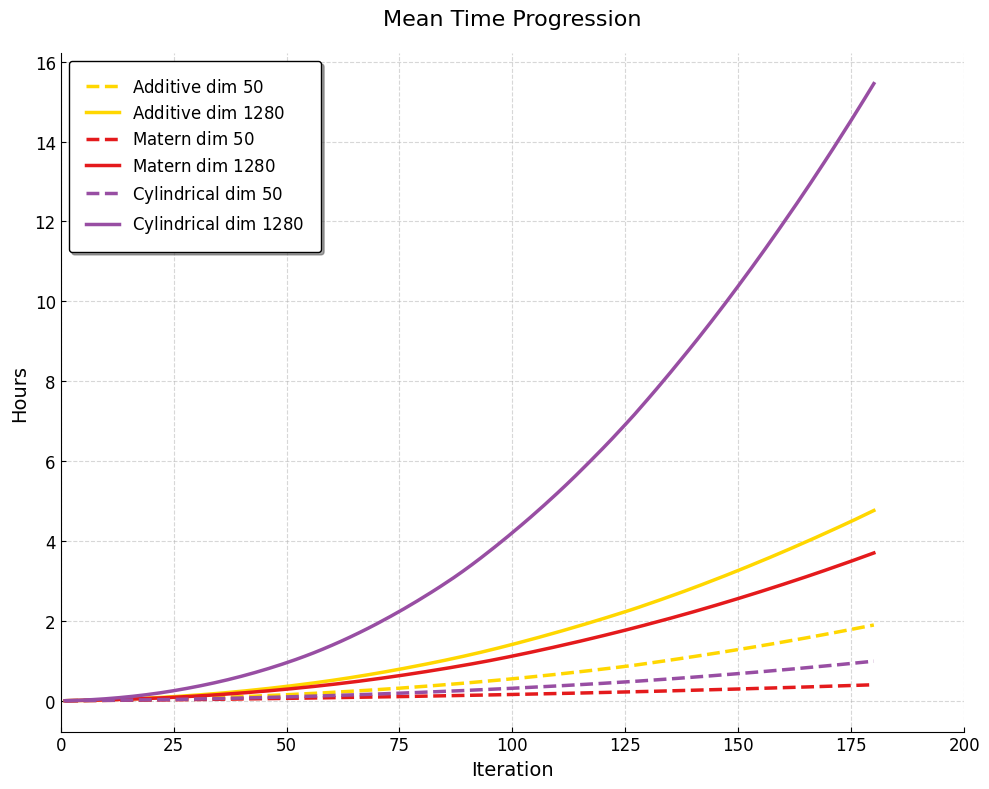

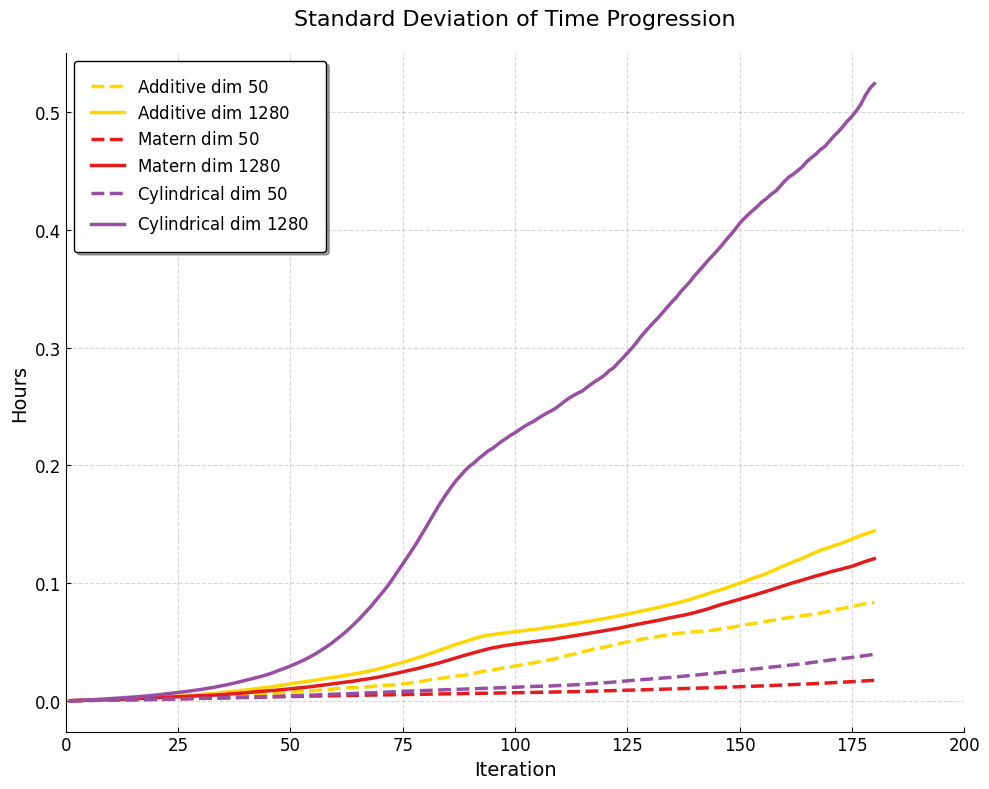

In [512]:
# Plot mean values in a separate figure
fig, ax = plt.subplots(figsize=(10, 8))
for key, mean_values in additive_times_mean.items():
    kernel_type = key.split("_")[0]
    dimension = key.split("_")[1]
    if "Conic" in key:  # Cylindrical kernel
        label = f"Cylindrical dim ${dimension}$"
        color = method_color_map.get("BOES cylindrical", '#000000')  # Use the color for Cylindrical
        linestyle = '--' if dimension == '50' else '-'  # Dashed line for dim 50
    elif "Matern" in key:  # Matern kernel
        label = f"Matern dim ${dimension}$"
        color = method_color_map.get("BOES", '#000000')  # Use the color for BOES
        linestyle = '--' if dimension == '50' else '-'  # Dashed line for dim 50
    elif "Additive" in key:  # Additive kernel
        label = f"Additive dim ${dimension}$"
        color = method_color_map.get("BOES additive", '#000000')  # Use the color for Additive
        linestyle = '--' if dimension == '50' else '-'  # Dashed line for dim 50
    else:
        continue
    ax.plot(
        np.arange(1, len(mean_values) + 1),
        mean_values,
        label=label.replace("1028", "1280"),
        color=color,
        linestyle=linestyle,
        linewidth=2.5  # Increased line width
    )

# Customize the plot
ax.set_title("Mean Time Progression", fontsize=16, pad=20)
ax.set_xlabel("Iteration", fontsize=14)
ax.set_ylabel("Hours", fontsize=14)
ax.set_xlim([0, 200])  # Adjust x-limits if necessary
ax.legend(fontsize=12, loc='upper left', frameon=True, fancybox=True, shadow=True, borderpad=1, edgecolor='black')
ax.grid(alpha=0.5, linestyle="--")  # Make grid lines lighter and dashed

# Make tick numbers bigger and point ticks inwards
ax.tick_params(axis='both', which='major', labelsize=12, direction='in')

# Remove the right and top borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig('results/' + dataset_name + save_name_modifier + '_time_mean.png', bbox_inches='tight')  # Save each plot separately

# Plot standard deviation values in a separate figure
fig, ax = plt.subplots(figsize=(10, 8))
for key, std_values in additive_times_std.items():
    kernel_type = key.split("_")[0]
    dimension = key.split("_")[1]
    if "Conic" in key:  # Cylindrical kernel
        label = f"Cylindrical dim ${dimension}$"
        color = method_color_map.get("BOES cylindrical", '#000000')  # Use the color for Cylindrical
        linestyle = '--' if dimension == '50' else '-'  # Dashed line for dim 50
    elif "Matern" in key:  # Matern kernel
        label = f"Matern dim ${dimension}$"
        color = method_color_map.get("BOES", '#000000')  # Use the color for BOES
        linestyle = '--' if dimension == '50' else '-'  # Dashed line for dim 50
    elif "Additive" in key:  # Additive kernel
        label = f"Additive dim ${dimension}$"
        color = method_color_map.get("BOES additive", '#000000')  # Use the color for Additive
        linestyle = '--' if dimension == '50' else '-'  # Dashed line for dim 50
    else:
        continue
    ax.plot(
        np.arange(1, len(std_values) + 1),
        std_values,
        label=label.replace("1028", "1280"),  # Replace 1028 with 1280 in the label
        color=color,
        linestyle=linestyle,
        linewidth=2.5  # Increased line width
    )

# Customize the plot
ax.set_title("Standard Deviation of Time Progression", fontsize=16, pad=20)
ax.set_xlabel("Iteration", fontsize=14)
ax.set_ylabel("Hours", fontsize=14)
ax.set_xlim([0, 200])  # Adjust x-limits if necessary
ax.legend(fontsize=12, loc='upper left', frameon=True, fancybox=True, shadow=True, borderpad=1, edgecolor='black')
ax.grid(alpha=0.5, linestyle="--")  # Make grid lines lighter and dashed

# Make tick numbers bigger and point ticks inwards
ax.tick_params(axis='both', which='major', labelsize=12, direction='in')

# Remove the right and top borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig('results/' + dataset_name + save_name_modifier + '_time_std.png', bbox_inches='tight')  # Save each plot separately